In [1]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import nnls
import scipy.linalg
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.optimize import nnls, minimize

from pyPAS.core.lt import MultiGaussianRF, PASLifetime, TimeResolution
from pyPAS.lifetime.generator import generate_random_lt_spectrum, generate_analytical_lt_spectrum
from pyPAS.lifetime.model import LifetimeModel
from pyspectrum import Spectrum
np.random.seed(42)

# system parmeters 

material

In [2]:
# characteristic lifetime distribution
dτ  = 5e-4
fine_τ_grid = np.arange(dτ, 5, dτ)

gauss_I_τ = np.vstack(np.array([0.40,  0.50, 0.10]))
gauss_τ = np.vstack(np.array([0.125, 0.45, 2.0]))
gauss_σ_τ = np.vstack(np.array([0.0015, 0.05, 0.3]))   # width in τ (ns)

true_τ_distribution = (gauss_I_τ / np.sqrt(2*np.pi*gauss_σ_τ**2) * np.exp(-(gauss_τ - fine_τ_grid) ** 2 / (2*gauss_σ_τ**2))).sum(axis=0)

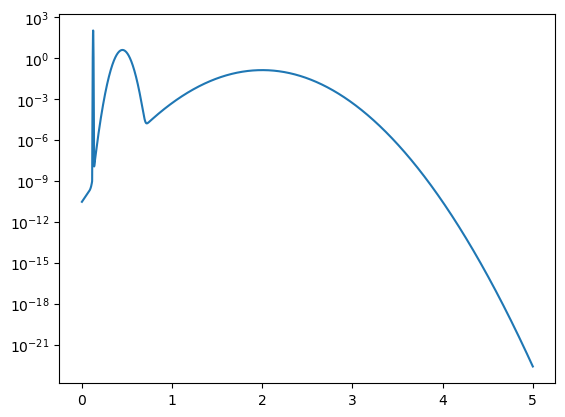

In [3]:
plt.semilogy(fine_τ_grid, true_τ_distribution)

In [4]:
irf_sigma = np.array([0.250/(2*np.sqrt(2*np.log(2)))])
IRF = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.zeros_like(irf_sigma))

In [5]:
lt_model = LifetimeModel("simulation", lifetimes=fine_τ_grid, intensities=true_τ_distribution)
time_step = 5e-3 # 5 picosecond
time = np.arange(-2, 40, time_step)
bg_frac = 0.001

expected_background = bg_frac/(time[-1]-time[0]) * np.ones_like(time)
analytical_spectrum = generate_analytical_lt_spectrum(time, lt_model, IRF, bg_frac)
random_spectrum = generate_random_lt_spectrum(time, lt_model, IRF, bg_frac, int(1e7))

In [6]:
# resolution function using response to impulse
impulse = np.zeros_like(time)
impulse[np.where(time>0)[0][0]] = 1/(time[1] - time[0])

res_fun = IRF.convolve(impulse,time)

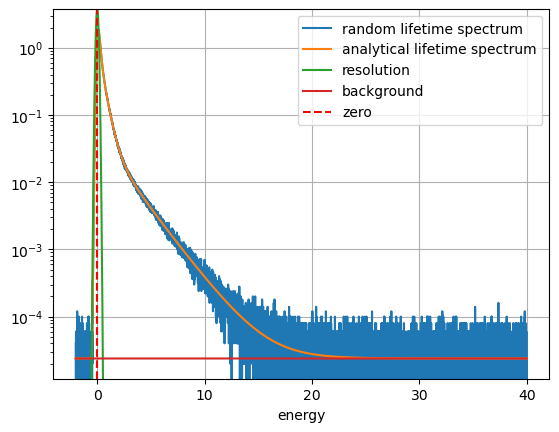

In [7]:
random_normalizer = random_spectrum.lifetime.integrate('energy')
(random_spectrum.lifetime/random_normalizer).plot(label='random lifetime spectrum', yscale='log')
analytical_spectrum.lifetime.plot(label='analytical lifetime spectrum', yscale='log')

plt.plot(time, res_fun, label='resolution')
plt.plot(time, expected_background, label='background')
plt.axvline(0, color='red', label='zero', ls='--')
plt.legend()
plt.ylim([expected_background[0]/2, np.max([res_fun.max(), analytical_spectrum.lifetime.max()])])


plt.grid()

# Inversion

In [8]:
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix
from matplotlib.colors import LogNorm
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.tikhonov import TikhonovRegularization

In [9]:
dτ = 5e-2
τ_grid = np.arange(dτ, 5, dτ)

dt = 5e-3
time_grid = np.arange(-2, 40, dt)

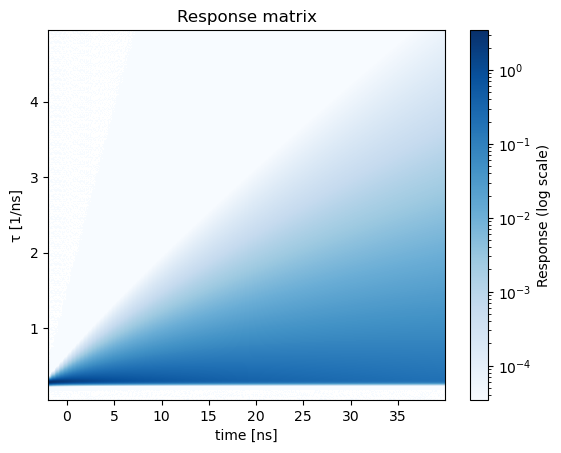

In [10]:
RM = _response_matrix(τ_grid, time_grid, IRF)
vmax = RM.max()
vmin = vmax / 1e5   # 5 orders of magnitude

plt.imshow(RM,
           cmap='Blues',
           origin='lower',
           extent=[time.min(), time.max(),
                   τ_grid.min(), τ_grid.max()],
           aspect='auto',
           norm=LogNorm(vmin=vmin, vmax=vmax))

plt.colorbar(label='Response (log scale)')
plt.title('Response matrix')
plt.xlabel('time [ns]')
plt.ylabel('τ [1/ns]')
plt.show()

In [34]:
tinvert = TikhonovRegularization(random_spectrum.lifetime.energy.values, τ_grid)
q, res = tinvert.invert(random_spectrum, initial_alpha=1e-5, error=True)

In [35]:
# the resulted optimization gives gives integral of 1 as expected
np.trapz(q, τ_grid), res

(0.9997225516943822,
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 9614.697267830516
        x: [-1.122e+01]
      nit: 2
    direc: [[ 1.000e+00]]
     nfev: 58)

In [36]:
np.exp(res.x)

array([1.33762567e-05])

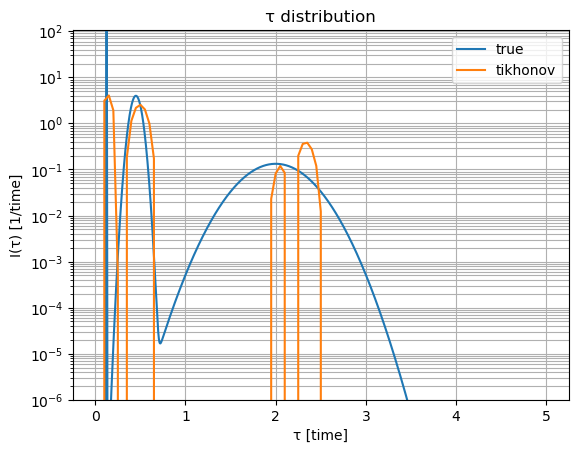

In [37]:
plt.plot(fine_τ_grid, true_τ_distribution, label="true")
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.yscale("log")
plt.ylim([1e-6, true_τ_distribution.max()])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()

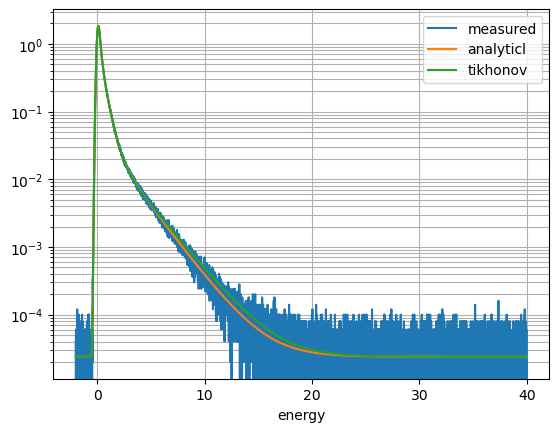

In [38]:
tikhonov_result_model = LifetimeModel('', τ_grid, q/np.trapz(q,τ_grid))
tikhonov_lifetime = generate_analytical_lt_spectrum(time,
                                                    tikhonov_result_model,
                                                    resolution=IRF,
                                                    background_fraction=bg_frac)
(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='measured')
(analytical_spectrum.lifetime/analytical_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='analyticl')
tikhonov_lifetime.lifetime.plot(label='tikhonov')

plt.grid(which="both")


plt.legend()

In [ ]:
mu_ML, *_ = np.linalg.lstsq(RM, data, rcond=None)

true_spectrum = np.zeros_like(tau_grid)
for tau, I in zip(true_taus, true_I):
    true_spectrum += I * np.exp(-(tau_grid - tau)**2 / (2*0.02**2))

plt.plot(tau_grid, true_spectrum, 'k--', label='True')
plt.plot(tau_grid, mu_ML, 'C3', label='ML')
plt.legend()

In [ ]:
# different noise yield various solutions
solutions = []

for _ in range(20):
    noisy = np.random.poisson(N_measured)
    sol, *_ = np.linalg.lstsq(RM, noisy, rcond=None)
    solutions.append(sol)

solutions = np.array(solutions)

plt.figure(figsize=(6,4.5))
for s in solutions:
    plt.plot(tau_grid, s, color='C3', alpha=0.2)

plt.xlabel('τ (ns)')
plt.ylabel('I(τ)')
plt.title('ML instability (noise amplification)')
plt.show()

In [ ]:
Sigma = np.diag(data + 1)

At_Sinv = RM.T @ np.linalg.inv(Sigma)
Cov = np.linalg.inv(At_Sinv @ RM)
corr = Cov / np.sqrt(Cov.diagonal() * Cov.diagonal().reshape((-1 ,1)))

plt.imshow(corr[1:-1,1:-1], cmap='Blues', origin='lower', extent=(0,1,0,1))
plt.colorbar()
plt.title('Response matrix')
plt.xlabel('Reco $x$')
plt.ylabel('True $x$')
plt.show()
R=RM

In [ ]:
def sqExpKernel_tau(a, b, params):
    amp, ell = params
    return np.exp(amp) * np.exp(-(a - b)**2 / (2*ell**2))

In [ ]:
from scipy.linalg import cho_factor, cho_solve

def GP_predict_lifetime(params, tau_grid, t, RM, data, kernel):

    # --- noise (Poisson) ---
    Sigma = np.diag(data + 1)

    # --- kernel in tau space ---
    K = kernel(tau_grid[:,None], tau_grid[:,None], params)

    # --- project to measurement space ---
    Ky = RM @ K @ RM.T + Sigma

    # --- Cholesky (like your code) ---
    L = cho_factor(Ky)

    # --- posterior mean ---
    alpha = cho_solve(L, data)
    mu = K @ RM.T @ alpha

    # --- posterior covariance ---
    cov = K - K @ RM.T @ cho_solve(L, RM @ K)

    return mu, cov

In [ ]:
R.shape

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize

# ═══════════════════════════════════════════════════════════════════════════
# 1. SIMULATE DATA WITH GAUSSIAN LIFETIME DISTRIBUTIONS
# ═══════════════════════════════════════════════════════════════════════════
dt  = 0.025  # ns
t   = np.arange(0, 20, dt)
n_t = len(t)

# Gaussian IRF
irf_sigma = 0.250 / (2*np.sqrt(2*np.log(2)))
IRF       = np.exp(-0.5*((t - 1.0)/irf_sigma)**2)
IRF      /= IRF.sum()

# Define lifetime distribution parameters
true_taus   = np.array([0.125, 0.45, 2.0])
true_I      = np.array([0.4,  0.5, 0.10])
true_sigmas = np.array([0.015, 0.05, 0.3])   # width in τ (ns)

# τ grid for "true" continuous distribution
tau_fine = np.arange(0.0025, 10, 0.0025)#np.logspace(np.log10(0.03), np.log10(5), 2000)

# Build I(τ) as sum of Gaussians
I_tau = np.zeros_like(tau_fine)
for tau0, amp, sig in zip(true_taus, true_I, true_sigmas):
    I_tau += amp * np.exp(-(tau_fine - tau0)**2 / (2*sig**2))

# normalize I(τ)
I_tau /= np.trapz(I_tau, tau_fine)

# Compute decay by integrating over τ
decay_true = np.zeros_like(t)
for j, tau in enumerate(tau_fine):
    decay_true += I_tau[j] * np.exp(-t/tau)

# Convolve with IRF
signal_conv = fftconvolve(decay_true, IRF, mode='full')[:n_t]
signal_conv = np.maximum(signal_conv, 0)


# Poisson sampling
total_counts = 1_000_0000
N_measured   = np.random.poisson(signal_conv/signal_conv.sum()*total_counts)

data = N_measured.astype(float)  # IMPORTANT: keep counts!

# ═══════════════════════════════════════════════════════════════════════════
# 2. BUILD RESPONSE MATRIX A (RM)
# ═══════════════════════════════════════════════════════════════════════════
#tau_grid = np.logspace(np.log10(0.05), np.log10(10), 200)
tau_grid = np.arange(0.025, 10, 0.025)
n_tau    = len(tau_grid)

RM = np.zeros((n_t, n_tau))

for j, tau in enumerate(tau_grid):
    col = fftconvolve(np.exp(-t/tau), IRF, mode='full')[:n_t]
    col = np.maximum(col, 0)

    # normalize each column → probability kernel
    col /= col.sum() 

    RM[:, j] = col
#RM =RM / tau_grid[None, :]
# ═══════════════════════════════════════════════════════════════════════════
# 3. "BROKEN" ML SOLUTION (for demonstration)
# ═══════════════════════════════════════════════════════════════════════════
mu_ML, *_ = np.linalg.lstsq(RM, data, rcond=None)

# ═══════════════════════════════════════════════════════════════════════════
# 4. GP KERNEL (log-τ space)
# ═══════════════════════════════════════════════════════════════════════════
def kernel_tau(a, b, params):
    amp, ell = params
    loga = np.log(a)
    logb = np.log(b.T)
    return np.exp(amp) * np.exp(-(loga - logb)**2 / (2*ell**2))

# ═══════════════════════════════════════════════════════════════════════════
# 5. GP PREDICTION (CORRECT FORMULATION)
# ═══════════════════════════════════════════════════════════════════════════
def GP_predict(params, tau_grid, RM, data):
    
    # Poisson noise approximation
    Sigma = np.diag(data + 1)

    # Prior covariance
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)

    # Project to measurement space
    Ky = RM @ K @ RM.T + Sigma

    # Solve
    L = cho_factor(Ky)
    alpha = cho_solve(L, data)

    # Posterior
    mu  = K @ RM.T @ alpha
    cov = K - K @ RM.T @ cho_solve(L, RM @ K)

    return mu, cov

# ═══════════════════════════════════════════════════════════════════════════
# 6. MARGINAL LIKELIHOOD
# ═══════════════════════════════════════════════════════════════════════════
def neg_log_likelihood(params):
    Sigma = np.diag(data + 1)
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    Ky = RM @ K @ RM.T + Sigma

    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        return np.inf

    alpha = np.linalg.solve(Ky, data)

    return data @ alpha + 2*np.sum(np.log(np.diag(L)))

# ═══════════════════════════════════════════════════════════════════════════
# 7. OPTIMIZE GP HYPERPARAMETERS
# ═══════════════════════════════════════════════════════════════════════════
x0 = [5.0, 1.0]

res = minimize(
    neg_log_likelihood,
    x0,
    bounds=((0, 20), (0.1, 1)),
    method='L-BFGS-B'
)

print("Optimized params:", res.x)

# ═══════════════════════════════════════════════════════════════════════════
# 8. GP RECONSTRUCTION
# ═══════════════════════════════════════════════════════════════════════════
mu_GP, cov_GP = GP_predict(res.x, tau_grid, RM, data)
std_GP = np.sqrt(np.diag(cov_GP))

# ═══════════════════════════════════════════════════════════════════════════
# 9. TRUE DISTRIBUTION (for comparison)
# ═══════════════════════════════════════════════════════════════════════════
#true_spectrum = np.zeros_like(tau_grid)
#for tau, I in zip(true_taus, true_I):
#    true_spectrum += I * np.exp(-(tau_grid - tau)**2 / (2*0.03**2))
#
## normalize for comparison
#true_spectrum /= np.trapz(true_spectrum, tau_grid)

# ═══════════════════════════════════════════════════════════════════════════
# 10. PLOTS
# ═══════════════════════════════════════════════════════════════════════════

# --- Time domain ---
plt.figure(figsize=(6,4))
plt.step(t, data, label="Measured")
plt.yscale('log')
plt.xlabel("Time (ns)")
plt.ylabel("Counts")
plt.title("Measured lifetime spectrum")
plt.legend()
plt.show()

# --- Tau domain comparison ---
plt.figure(figsize=(6,4))

plt.plot(tau_grid, mu_GP / np.trapz(mu_GP, tau_grid),
         color='k', label="GP")

plt.fill_between(
    tau_grid,
    (mu_GP-std_GP)/np.trapz(mu_GP, tau_grid),
    (mu_GP+std_GP)/np.trapz(mu_GP, tau_grid),
    color='gray', alpha=0.3
)

plt.plot(tau_fine, I_tau/np.trapz(I_tau, tau_fine), 'k--', label="True")

plt.xscale('log')
plt.xlabel("Lifetime τ (ns)")
plt.ylabel("I(τ)")
plt.legend()
plt.title("Lifetime reconstruction")
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 11. FORWARD MODEL: GP → TIME DOMAIN
# ═══════════════════════════════════════════════════════════════════════════

# Reconstruct time signal from GP solution
signal_GP = RM @ mu_GP

# Normalize to same total counts as data
signal_GP = signal_GP / signal_GP.sum() * data.sum()

# Also forward ML for comparison (optional)
signal_ML = RM @ mu_ML
signal_ML = signal_ML / signal_ML.sum() * data.sum()

# ═══════════════════════════════════════════════════════════════════════════
# 12. PLOT: DATA vs GP vs ML (TIME DOMAIN)
# ═══════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(6,4))

# measured data
plt.step(t, data, where='mid', label='Measured', color='k')

# GP reconstruction
plt.plot(t, signal_GP, label='GP forward model', linewidth=2)

# ML reconstruction (optional, usually noisy)
plt.plot(t, signal_ML, '--', label='ML forward', alpha=0.7)

plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('Counts')
plt.title('Time-domain reconstruction check')
plt.ylim([1e-2,1e6])
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize

# ═══════════════════════════════════════════════════════════════════════════
# 1. SIMULATE DATA (GAUSSIAN LIFETIME DISTRIBUTIONS)
# ═══════════════════════════════════════════════════════════════════════════
dt  = 0.050
t   = np.arange(0, 50, dt)
n_t = len(t)

# IRF
irf_sigma = 0.250 / (2*np.sqrt(2*np.log(2)))
IRF = np.exp(-0.5*((t - 1.0)/irf_sigma)**2)
IRF /= IRF.sum()

# True distribution
true_taus   = np.array([0.125, 0.45, 2.0])
true_I      = np.array([0.40,  0.50, 0.10])
true_sigmas = np.array([0.015, 0.05, 0.3])

tau_fine = np.arange(0.025, 5, 0.0025)

I_tau_true = np.zeros_like(tau_fine)
for tau0, amp, sig in zip(true_taus, true_I, true_sigmas):
    I_tau_true += amp * np.exp(-(tau_fine - tau0)**2 / (2*sig**2))

I_tau_true /= np.trapz(I_tau_true, tau_fine)

# forward model
decay_true = np.zeros_like(t)
for j, tau in enumerate(tau_fine):
    decay_true += I_tau_true[j] * np.exp(-t/tau)

signal_conv = fftconvolve(decay_true, IRF, mode='full')[:n_t]
signal_conv = np.maximum(signal_conv, 0)

total_counts = 1_000_000
data = np.random.poisson(signal_conv/signal_conv.sum()*total_counts).astype(float)

# ═══════════════════════════════════════════════════════════════════════════
# 2. RESPONSE MATRIX
# ═══════════════════════════════════════════════════════════════════════════
tau_grid = np.arange(0.025, 5, 0.025)
n_tau = len(tau_grid)

RM = np.zeros((n_t, n_tau))
for j, tau in enumerate(tau_grid):
    col = fftconvolve(np.exp(-t/tau), IRF, mode='full')[:n_t]
    col = np.maximum(col, 0)
    col /= col.sum() + 1e-12
    RM[:, j] = col

# ═══════════════════════════════════════════════════════════════════════════
# 3. ML (BROKEN SOLUTION)
# ═══════════════════════════════════════════════════════════════════════════
mu_ML, *_ = np.linalg.lstsq(RM, data, rcond=None)

# ═══════════════════════════════════════════════════════════════════════════
# 4. KERNEL (log-τ)
# ═══════════════════════════════════════════════════════════════════════════
def kernel_tau(a, b, params):
    log_sigma, log_ell = params
    loga = np.log(a)
    logb = np.log(b.T)
    sigma2 = np.exp(log_sigma)
    ell2   = np.exp(log_ell)**2
    return sigma2 * np.exp(-(loga - logb)**2 / (2*ell2))

# ═══════════════════════════════════════════════════════════════════════════
# 5. STANDARD GP (LINEAR)
# ═══════════════════════════════════════════════════════════════════════════
def GP_predict(params):
    Sigma = np.diag(data + 1)
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    Ky = RM @ K @ RM.T + Sigma + 1e-9*np.eye(n_t)

    L = cho_factor(Ky)
    alpha = cho_solve(L, data)

    mu = K @ RM.T @ alpha
    cov = K - K @ RM.T @ cho_solve(L, RM @ K)

    return mu, cov

def neg_log_likelihood(params):
    Sigma = np.diag(data + 1)
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    Ky = RM @ K @ RM.T + Sigma + 1e-9*np.eye(n_t)

    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        return np.inf

    alpha = np.linalg.solve(Ky, data)
    return 0.5*(data @ alpha + 2*np.sum(np.log(np.diag(L))))

# optimize
res = minimize(neg_log_likelihood, [5.0, 0.0], bounds=((0,20),(-5,5)))
params_opt = res.x

mu_GP, cov_GP = GP_predict(params_opt)
std_GP = np.sqrt(np.diag(cov_GP))

# ═══════════════════════════════════════════════════════════════════════════
# 6. POSITIVE GP (SOFTPLUS)
# ═══════════════════════════════════════════════════════════════════════════
def softplus(x):
    return np.log1p(np.exp(x))

def neg_log_posterior_f(f, K, RM, data, Sigma_inv):
    I_tau = softplus(f)
    model = RM @ I_tau

    residual = data - model
    chi2 = residual @ Sigma_inv @ residual

    prior = f @ np.linalg.solve(K, f)

    return 0.5 * (chi2 + prior)

def solve_positive_gp(params):
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    Sigma = np.diag(data + 1)
    Sigma_inv = np.linalg.inv(Sigma)

    # initialize from linear GP
    f0 = np.log(np.clip(mu_GP, 1e-12, None))

    res = minimize(
        neg_log_posterior_f,
        f0,
        args=(K, RM, data, Sigma_inv),
        method='L-BFGS-B'
    )

    f_opt = res.x
    I_tau = softplus(f_opt)

    return I_tau

I_pos = solve_positive_gp(params_opt)

# ═══════════════════════════════════════════════════════════════════════════
# 7. FORWARD MODEL CHECK
# ═══════════════════════════════════════════════════════════════════════════
signal_GP = RM @ mu_GP
signal_GP = signal_GP / signal_GP.sum() * data.sum()

signal_pos = RM @ I_pos
signal_pos = signal_pos / signal_pos.sum() * data.sum()

# ═══════════════════════════════════════════════════════════════════════════
# 8. TRUE PROJECTED ON GRID
# ═══════════════════════════════════════════════════════════════════════════
true_interp = np.interp(tau_grid, tau_fine, I_tau_true)
true_interp /= np.trapz(true_interp, tau_grid)

# ═══════════════════════════════════════════════════════════════════════════
# 9. PLOTS
# ═══════════════════════════════════════════════════════════════════════════

# --- τ domain ---
plt.figure(figsize=(6,4))

plt.plot(tau_grid, mu_GP/np.trapz(mu_GP, tau_grid),
         label='GP (linear)', color='k')

plt.plot(tau_grid, I_pos/np.trapz(I_pos, tau_grid),
         label='GP (positive)', linewidth=2)

plt.plot(tau_grid, true_interp,
         'k--', label='True')

plt.xscale('log')
plt.xlabel('τ (ns)')
plt.ylabel('I(τ)')
plt.legend()
plt.title('Lifetime distribution reconstruction')
plt.show()

# --- time domain ---
plt.figure(figsize=(6,4))

plt.step(t, data, where='mid', label='Measured', color='k')

plt.plot(t, signal_GP, label='GP forward')
plt.plot(t, signal_pos, label='Positive GP forward')

plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('Counts')
plt.legend()
plt.title('Forward model validation')
plt.show()

# --- residuals ---
residuals = (data - signal_pos) / np.sqrt(data + 1)

plt.figure(figsize=(6,3))
plt.plot(t, residuals, '.')
plt.axhline(0, color='k')
plt.xlabel('Time (ns)')
plt.ylabel('Pull')
plt.title('Residuals (positive GP)')
plt.show()

In [ ]:
len(np.arange(0.05, 5, 0.05))

In [ ]:
plt.plot(I_pos)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.optimize import minimize
from scipy.linalg import cho_factor, cho_solve

# ═══════════════════════════════════════════════════════════════════════════
# 1. SIMULATE DATA (same structure as yours)
# ═══════════════════════════════════════════════════════════════════════════
dt  = 0.05
t   = np.arange(0, 50, dt)
n_t = len(t)

irf_sigma = 0.250 / (2*np.sqrt(2*np.log(2)))
IRF = np.exp(-0.5*((t - 1.0)/irf_sigma)**2)
IRF /= IRF.sum()

true_taus   = np.array([0.125, 0.45, 2.0])
true_I      = np.array([0.4, 0.5, 0.1])
true_sigmas = np.array([0.015, 0.05, 0.3])

tau_fine = np.logspace(np.log10(0.03), np.log10(10), 2000)

I_tau_true = np.zeros_like(tau_fine)
for tau0, amp, sig in zip(true_taus, true_I, true_sigmas):
    I_tau_true += amp * np.exp(-(tau_fine - tau0)**2 / (2*sig**2))

I_tau_true /= np.trapz(I_tau_true, tau_fine)

decay_true = np.zeros_like(t)
for j, tau in enumerate(tau_fine):
    decay_true += I_tau_true[j] * np.exp(-t/tau)

signal = fftconvolve(decay_true, IRF, mode='full')[:n_t]
signal = np.maximum(signal, 0)

data = np.random.poisson(signal/signal.sum()*1_000_000).astype(float)

# ═══════════════════════════════════════════════════════════════════════════
# 2. RESPONSE MATRIX (log-τ consistent!)
# ═══════════════════════════════════════════════════════════════════════════
tau_grid = np.logspace(np.log10(0.05), np.log10(10), 200)
n_tau = len(tau_grid)

RM = np.zeros((n_t, n_tau))
for j, tau in enumerate(tau_grid):
    col = fftconvolve(np.exp(-t/tau), IRF, mode='full')[:n_t]
    col = np.maximum(col, 0)
    col /= col.sum() + 1e-12
    RM[:, j] = col

# 🔥 measure correction
A = RM / tau_grid[None, :]

# ═══════════════════════════════════════════════════════════════════════════
# 3. KERNEL (log-τ RBF)
# ═══════════════════════════════════════════════════════════════════════════
def kernel_tau(a, b, params):
    log_sigma, log_ell = params
    loga = np.log(a)
    logb = np.log(b.T)
    sigma2 = np.exp(log_sigma)
    ell2   = np.exp(log_ell)**2
    return sigma2 * np.exp(-(loga - logb)**2 / (2*ell2))

# ═══════════════════════════════════════════════════════════════════════════
# 4. NEGATIVE LOG POSTERIOR + GRADIENT (KEY PART)
# ═══════════════════════════════════════════════════════════════════════════
def neg_log_post(f, K, A, y):
    I = np.exp(f)
    lam = A @ I + 1e-12

    # Poisson likelihood
    nll = np.sum(lam - y * np.log(lam))

    # GP prior
    L = np.linalg.cholesky(K + 1e-9*np.eye(len(K)))
    alpha = cho_solve((L, True), f)
    prior = 0.5 * f @ alpha

    return nll + prior

def grad_neg_log_post(f, K, A, y):
    I = np.exp(f)
    lam = A @ I + 1e-12

    # gradient of likelihood
    r = 1 - y / lam
    grad_lik = A.T @ r * I

    # prior
    L = np.linalg.cholesky(K + 1e-9*np.eye(len(K)))
    alpha = cho_solve((L, True), f)

    return grad_lik + alpha

# ═══════════════════════════════════════════════════════════════════════════
# 5. MAP SOLUTION (Laplace center)
# ═══════════════════════════════════════════════════════════════════════════
params = [2.0, 0.5]
K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)

f0 = np.zeros(n_tau)

res = minimize(
    neg_log_post,
    f0,
    jac=grad_neg_log_post,
    args=(K, A, data),
    method='L-BFGS-B'
)

f_map = res.x
I_map = np.exp(f_map)

# ═══════════════════════════════════════════════════════════════════════════
# 6. LAPLACE COVARIANCE (UNCERTAINTY)
# ═══════════════════════════════════════════════════════════════════════════
lam = A @ I_map

W = A.T @ (lam[:,None] * A)

K_inv = np.linalg.inv(K + 1e-9*np.eye(n_tau))
Sigma_post = np.linalg.inv(K_inv + W)

std_f = np.sqrt(np.diag(Sigma_post))
std_I = I_map * std_f  # propagate through exp

# ═══════════════════════════════════════════════════════════════════════════
# 7. FORWARD CHECK
# ═══════════════════════════════════════════════════════════════════════════
signal_rec = A @ I_map
signal_rec = signal_rec / signal_rec.sum() * data.sum()

# true projected
true_interp = np.interp(tau_grid, tau_fine, I_tau_true)
true_interp /= np.trapz(true_interp, tau_grid)

# ═══════════════════════════════════════════════════════════════════════════
# 8. PLOTS
# ═══════════════════════════════════════════════════════════════════════════

# τ domain
plt.figure(figsize=(6,4))
plt.plot(tau_grid, I_map/np.trapz(I_map, tau_grid), label='Laplace GP')
plt.plot(tau_grid, true_interp, 'k--', label='True')

plt.fill_between(
    tau_grid,
    (I_map-std_I)/np.trapz(I_map, tau_grid),
    (I_map+std_I)/np.trapz(I_map, tau_grid),
    alpha=0.3
)

plt.xscale('log')
plt.xlabel('τ (ns)')
plt.ylabel('I(τ)')
plt.legend()
plt.title('Non-negative GP (Laplace)')
plt.show()

# time domain
plt.figure(figsize=(6,4))
plt.step(t, data, where='mid', label='Measured', color='k')
plt.plot(t, signal_rec, label='Reconstruction')

plt.yscale('log')
plt.xlabel('Time (ns)')
plt.ylabel('Counts')
plt.legend()
plt.title('Forward check')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize

# ═══════════════════════════════════════════════════════════════════════════
# 1. SIMULATE DATA (GAUSSIAN LIFETIME DISTRIBUTIONS)
# ═══════════════════════════════════════════════════════════════════════════
dt  = 0.050
t   = np.arange(0, 50, dt)
n_t = len(t)

irf_sigma = 0.250 / (2*np.sqrt(2*np.log(2)))
IRF = np.exp(-0.5*((t - 1.0)/irf_sigma)**2)
IRF /= IRF.sum()

true_taus   = np.array([0.125, 0.45, 2.0])
true_I      = np.array([0.40,  0.50, 0.10])
true_sigmas = np.array([0.015, 0.05, 0.3])

tau_fine = np.arange(0.025, 5, 0.0025)

I_tau_true = np.zeros_like(tau_fine)
for tau0, amp, sig in zip(true_taus, true_I, true_sigmas):
    I_tau_true += amp * np.exp(-(tau_fine - tau0)**2 / (2*sig**2))
I_tau_true /= np.trapz(I_tau_true, tau_fine)

decay_true = np.zeros_like(t)
for j, tau in enumerate(tau_fine):
    decay_true += I_tau_true[j] * np.exp(-t/tau)

signal_conv = fftconvolve(decay_true, IRF, mode='full')[:n_t]
signal_conv = np.maximum(signal_conv, 0)

total_counts = 1_000_000
data = np.random.poisson(signal_conv / signal_conv.sum() * total_counts).astype(float)

# ═══════════════════════════════════════════════════════════════════════════
# 2. RESPONSE MATRIX
# Each column = IRF ⊛ exp(-t/τ), normalized to sum-to-1 (probability kernel).
# Forward model: counts(t) = N_total * RM @ I_tau
# where I_tau integrates to 1 (probability distribution over τ).
# ═══════════════════════════════════════════════════════════════════════════
tau_grid = np.arange(0.025, 5, 0.025)
n_tau = len(tau_grid)

RM = np.zeros((n_t, n_tau))
for j, tau in enumerate(tau_grid):
    col = fftconvolve(np.exp(-t/tau), IRF, mode='full')[:n_t]
    col = np.maximum(col, 0)
    col /= col.sum() + 1e-12
    RM[:, j] = col

# ═══════════════════════════════════════════════════════════════════════════
# 3. KERNEL (log-τ space)
# ═══════════════════════════════════════════════════════════════════════════
def kernel_tau(a, b, params):
    log_sigma, log_ell = params
    loga = np.log(a)
    logb = np.log(b.T)
    sigma2 = np.exp(log_sigma)
    ell2   = np.exp(log_ell)**2
    return sigma2 * np.exp(-(loga - logb)**2 / (2*ell2))

# ═══════════════════════════════════════════════════════════════════════════
# 4. LINEAR GP (for initialization and comparison)
# ═══════════════════════════════════════════════════════════════════════════
def GP_predict_linear(params):
    Sigma = np.diag(data + 1)
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    Ky = RM @ K @ RM.T + Sigma + 1e-9*np.eye(n_t)
    L = cho_factor(Ky)
    alpha = cho_solve(L, data)
    mu  = K @ RM.T @ alpha
    cov = K - K @ RM.T @ cho_solve(L, RM @ K)
    return mu, cov

def neg_log_likelihood_linear(params):
    Sigma = np.diag(data + 1)
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    Ky = RM @ K @ RM.T + Sigma + 1e-9*np.eye(n_t)
    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        return np.inf
    alpha = np.linalg.solve(Ky, data)
    return 0.5*(data @ alpha + 2*np.sum(np.log(np.diag(L))))

res = minimize(neg_log_likelihood_linear, [5.0, 0.0], bounds=((0,20),(-5,5)))
params_opt = res.x
print(f"Optimized GP params: log_sigma={params_opt[0]:.3f}, log_ell={params_opt[1]:.3f}")

mu_GP_linear, cov_GP_linear = GP_predict_linear(params_opt)
std_GP_linear = np.sqrt(np.diag(cov_GP_linear))

# ═══════════════════════════════════════════════════════════════════════════
# 5. POSITIVE GP — FIXED
#
# THREE bugs in the original:
#
# Bug 1 — Softplus floor: softplus(f) = log(1+exp(f)) → min ≈ 0.693 as f→-∞.
#   This leaves a spurious constant floor across ALL tau, creating a fake
#   long-lifetime background that ruins the tail fit.
#   FIX: use exp(f) instead — true zero floor, clean log-normal prior geometry.
#
# Bug 2 — Missing amplitude: RM columns sum to 1, so RM @ I_tau gives a
#   normalized kernel, not counts. The positive optimizer has no free scale,
#   so it compensates by pushing I_tau values up everywhere, destroying shape.
#   FIX: add a free log-amplitude parameter N_total alongside f.
#
# Bug 3 — Scale mismatch in prior: the prior f @ K⁻¹ @ f acts on latent f,
#   but K was optimized for the scale of I_tau, not log(I_tau). The relative
#   chi²/prior weighting is therefore wrong.
#   FIX: re-optimize K (or at minimum keep params_opt but accept this is
#   approximate) — the exp(f) parametrization makes the prior geometry
#   much more natural in log-space.
# ═══════════════════════════════════════════════════════════════════════════

def neg_log_posterior_positive(theta, K, RM, data):
    """
    theta = [log_N, f_0, f_1, ..., f_{n_tau-1}]
    I_tau = exp(f)        (positive, no floor)
    model = N * RM @ I_tau  (counts, properly scaled)
    Likelihood: Gaussian with Poisson variance Sigma = diag(data + 1)
    Prior: f ~ GP(0, K)
    """
    log_N = theta[0]
    f     = theta[1:]

    N     = np.exp(log_N)
    I_tau = np.exp(f)                    # positive, true zero asymptote

    model    = N * (RM @ I_tau)          # predicted counts
    residual = data - model
    sigma2   = data + 1                  # Poisson variance

    chi2  = np.sum(residual**2 / sigma2)
    prior = f @ np.linalg.solve(K, f)   # f is log-scale, matches K geometry

    return 0.5 * (chi2 + prior)

def solve_positive_gp(params, mu_linear):
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    K += 1e-9 * np.eye(n_tau)

    # Initialize:
    #   N_init  = total data counts
    #   f_init  = log of clipped linear GP (already a reasonable I_tau shape)
    N_init    = data.sum()
    I_init    = np.clip(mu_linear, 1e-12, None)
    I_init   /= np.trapz(I_init, tau_grid) + 1e-12  # normalize to prob dist
    f_init    = np.log(I_init)

    theta0 = np.concatenate([[np.log(N_init)], f_init])

    res = minimize(
        neg_log_posterior_positive,
        theta0,
        args=(K, RM, data),
        method='L-BFGS-B',
        options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8}
    )

    log_N_opt = res.x[0]
    f_opt     = res.x[1:]
    N_opt     = np.exp(log_N_opt)
    I_tau_opt = np.exp(f_opt)

    return I_tau_opt, N_opt

I_pos, N_pos = solve_positive_gp(params_opt, mu_GP_linear)
print(f"Optimized total counts N = {N_pos:.0f}  (data sum = {data.sum():.0f})")

# ═══════════════════════════════════════════════════════════════════════════
# 6. FORWARD MODEL CHECK
# ═══════════════════════════════════════════════════════════════════════════
signal_linear = RM @ np.clip(mu_GP_linear, 0, None)
signal_linear = signal_linear / signal_linear.sum() * data.sum()

# For positive GP: N_pos * RM @ I_pos already has correct scale
signal_pos = N_pos * (RM @ I_pos)

# ═══════════════════════════════════════════════════════════════════════════
# 7. TRUE DISTRIBUTION PROJECTED ON GRID
# ═══════════════════════════════════════════════════════════════════════════
true_interp = np.interp(tau_grid, tau_fine, I_tau_true)
true_interp /= np.trapz(true_interp, tau_grid)

# ═══════════════════════════════════════════════════════════════════════════
# 8. PLOTS
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 1, figsize=(8, 11))
fig.suptitle("Positron Lifetime GP Reconstruction (Fixed)", fontsize=13, fontweight='bold')

# --- τ domain ---
ax = axes[0]
norm_linear = np.trapz(np.clip(mu_GP_linear, 0, None), tau_grid)
norm_pos    = np.trapz(I_pos, tau_grid)

ax.plot(tau_grid, np.clip(mu_GP_linear, 0, None) / norm_linear,
        color='steelblue', label='GP (linear, clipped)', alpha=0.8)
ax.fill_between(tau_grid,
    np.clip(mu_GP_linear - std_GP_linear, 0, None) / norm_linear,
    np.clip(mu_GP_linear + std_GP_linear, 0, None) / norm_linear,
    color='steelblue', alpha=0.2)

ax.plot(tau_grid, I_pos / norm_pos,
        color='orangered', linewidth=2, label='GP (positive, fixed)')

ax.plot(tau_grid, true_interp,
        'k--', linewidth=1.5, label='True I(τ)')

ax.set_xscale('log')
ax.set_xlabel('τ (ns)')
ax.set_ylabel('I(τ)  [normalized]')
ax.legend()
ax.set_title('Lifetime distribution reconstruction')
ax.set_xlim([tau_grid[0], tau_grid[-1]])

# --- time domain ---
ax = axes[1]
ax.step(t, data/data.sum(), where='mid', color='k', alpha=0.5, label='Measured', linewidth=0.8)
ax.plot(t, signal_linear/signal_linear.sum(), color='steelblue', label='Linear GP forward')
ax.plot(t, signal_pos/signal_pos.sum(),    color='orangered', label='Positive GP forward')
ax.set_yscale('log')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Counts')
ax.legend()
ax.set_title('Forward model validation (log scale)')

# --- residuals (pull) ---
ax = axes[2]
pull_linear = (data/data.sum() - signal_linear/signal_linear.sum()) / np.sqrt(data/data.sum() + 1)
pull_pos    = (data/data.sum() - signal_pos/signal_pos.sum())    / np.sqrt(data/data.sum() + 1)

ax.plot(t, pull_linear, '.', color='steelblue', markersize=2, alpha=0.7, label='Linear GP')
ax.plot(t, pull_pos,    '.', color='orangered', markersize=2, alpha=0.7, label='Positive GP (fixed)')
ax.axhline(0,  color='k',    linewidth=1)
ax.axhline(+2, color='gray', linewidth=0.7, linestyle='--')
ax.axhline(-2, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Pull  (data − model) / σ')
ax.set_title('Residuals')
ax.set_ylim([-5, 5])
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
pull_linear = (data/data.sum() - signal_linear/signal_linear.sum()) / np.sqrt(data/data.sum() + 1)
pull_pos    = (data/data.sum() - signal_pos/signal_pos.sum())    / np.sqrt(data/data.sum() + 1)

plt.plot(t, pull_linear, '.', color='steelblue', markersize=2, alpha=0.7, label='Linear GP')
plt.plot(t, pull_pos,    '.', color='orangered', markersize=2, alpha=0.7, label='Positive GP (fixed)')
plt.axhline(0,  color='k',    linewidth=1)
#plt.axhline(+2, color='gray', linewidth=0.7, linestyle='--')
#plt.axhline(-2, color='gray', linewidth=0.7, linestyle='--')
plt.xlabel('Time (ns)')
plt.ylabel('Pull  (data − model) / σ')
plt.title('Residuals')
#plt.ylim([-5, 5])
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize

# ═══════════════════════════════════════════════════════════════════════════
# 1. SIMULATE DATA
# ═══════════════════════════════════════════════════════════════════════════
dt  = 0.050
t   = np.arange(0, 15, dt)
n_t = len(t)

irf_sigma = 0.250 / (2*np.sqrt(2*np.log(2)))
IRF = np.exp(-0.5*((t - 1.0)/irf_sigma)**2)
IRF /= IRF.sum()

true_taus   = np.array([0.2, 0.5, 2.0])
true_I      = np.array([0.40,  0.50, 0.10])
true_sigmas = np.array([0.015, 0.05, 0.3])
tau_fine = np.arange(0.025, 5, 0.0025)

I_tau_true = np.zeros_like(tau_fine)
for tau0, amp, sig in zip(true_taus, true_I, true_sigmas):
    I_tau_true += amp * np.exp(-(tau_fine - tau0)**2 / (2*sig**2))
I_tau_true /= np.trapz(I_tau_true, tau_fine)

decay_true = np.zeros_like(t)
for j, tau in enumerate(tau_fine):
    decay_true += I_tau_true[j] * np.exp(-t/tau)

signal_conv = fftconvolve(decay_true, IRF, mode='full')[:n_t]
signal_conv = np.maximum(signal_conv, 0)

total_counts = 1_000_000
data = np.random.poisson(signal_conv / signal_conv.sum() * total_counts).astype(float)

# ═══════════════════════════════════════════════════════════════════════════
# 2. RESPONSE MATRIX
#    Each column: IRF ⊛ exp(-t/τ), normalized so sum_t RM[:,j] = 1.
#    Forward model: counts(t) = N * RM @ c
#    where c_j = I_tau(τ_j) * dtau  are DISCRETE PROBABILITY WEIGHTS (sum≈1).
# ═══════════════════════════════════════════════════════════════════════════
tau_grid = np.arange(0.025, 5, 0.025)
n_tau    = len(tau_grid)
dtau     = np.diff(tau_grid)[0]   # = 0.025 ns

RM = np.zeros((n_t, n_tau))
for j, tau in enumerate(tau_grid):
    col = fftconvolve(np.exp(-t/tau), IRF, mode='full')[:n_t]
    col = np.maximum(col, 0)
    col /= col.sum() + 1e-12
    RM[:, j] = col

# ═══════════════════════════════════════════════════════════════════════════
# 3. KERNEL (log-τ space)
# ═══════════════════════════════════════════════════════════════════════════
def kernel_tau(a, b, params):
    log_sigma, log_ell = params
    loga = np.log(a); logb = np.log(b.T)
    return np.exp(log_sigma) * np.exp(-(loga - logb)**2 / (2*np.exp(log_ell)**2))

# ═══════════════════════════════════════════════════════════════════════════
# 4. LINEAR GP (for initialization and comparison)
# ═══════════════════════════════════════════════════════════════════════════
def GP_predict_linear(params):
    Sigma = np.diag(data + 1)
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    Ky = RM @ K @ RM.T + Sigma + 1e-9*np.eye(n_t)
    L = cho_factor(Ky)
    alpha = cho_solve(L, data)
    mu  = K @ RM.T @ alpha
    cov = K - K @ RM.T @ cho_solve(L, RM @ K)
    return mu, cov

def neg_log_likelihood_linear(params):
    Sigma = np.diag(data + 1)
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    Ky = RM @ K @ RM.T + Sigma + 1e-9*np.eye(n_t)
    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        return np.inf
    alpha = np.linalg.solve(Ky, data)
    return 0.5*(data @ alpha + 2*np.sum(np.log(np.diag(L))))

res_lin = minimize(neg_log_likelihood_linear, [5.0, 0.0], bounds=((0,20),(-5,5)))
params_opt = res_lin.x
print(f"Optimized params: log_sigma={params_opt[0]:.3f}, log_ell={params_opt[1]:.3f}")

mu_GP_linear, cov_GP_linear = GP_predict_linear(params_opt)
std_GP_linear = np.sqrt(np.diag(cov_GP_linear))

# ═══════════════════════════════════════════════════════════════════════════
# 5. POSITIVE GP — CORRECT FORMULATION
#
# Parameterization:
#   c_j  = exp(f_j)             probability weights (dimensionless)
#   c_j  = I_tau(τ_j) * dtau   so sum_j c_j ≈ integral I_tau dτ = 1
#
# Forward model:
#   model(t) = N * RM @ c       (counts)
#
# Prior:
#   (f - m) ~ GP(0, K)   with mean  m = log(1/n_tau)
#
#   WHY THIS MEAN? At times where data→0, the posterior for f collapses
#   to the prior. With m=0, the prior says exp(f)=1 everywhere — a large
#   spurious amplitude at all lifetimes. With m=log(1/n_tau), the prior
#   says exp(f)=1/n_tau — the uniform distribution over bins — which
#   contributes only ~1/n_tau counts per bin: effectively zero signal.
#   This prevents the tail artifact entirely.
#
# Bugs fixed vs. original code:
#   1. softplus → exp  (true zero floor, no constant offset)
#   2. free log_N  (amplitude separated from shape)
#   3. work with c=I_tau*dtau  (correct quadrature, no 40× scale error)
#   4. prior mean m=log(1/n_tau)  (prior pulls to zero, not to 1)
# ═══════════════════════════════════════════════════════════════════════════

m_prior = np.log(1.0 / n_tau)   # ≈ -5.3 for n_tau=199

def neg_log_posterior(theta, K, RM, data, m_prior):
    """
    theta = [log_N, f_0, ..., f_{n_tau-1}]
    c     = exp(f)          probability weights  (= I_tau * dtau)
    model = N * RM @ c      predicted counts
    """
    log_N = theta[0]
    f     = theta[1:]
    N     = np.exp(log_N)
    c     = np.exp(f)

    model    = N * (RM @ c)
    residual = data - model
    chi2     = np.sum(residual**2 / (data + 1))

    f_centered = f - m_prior
    prior      = f_centered @ np.linalg.solve(K, f_centered)

    return 0.5 * (chi2 + prior)

def solve_positive_gp(params, mu_linear):
    K = kernel_tau(tau_grid[:,None], tau_grid[:,None], params)
    K += 1e-9 * np.eye(n_tau)

    # Initialize from linear GP: convert density → weights
    N_init  = data.sum()
    I_init  = np.clip(mu_linear, 1e-12, None)
    I_init /= np.trapz(I_init, tau_grid) + 1e-12
    c_init  = np.clip(I_init * dtau, 1e-12, None)
    f_init  = np.log(c_init)

    theta0 = np.concatenate([[np.log(N_init)], f_init])

    res = minimize(
        neg_log_posterior,
        theta0,
        args=(K, RM, data, m_prior),
        method='L-BFGS-B',
        options={'maxiter': 5000, 'ftol': 1e-14, 'gtol': 1e-9}
    )

    N_opt = np.exp(res.x[0])
    c_opt = np.exp(res.x[1:])   # probability weights
    I_opt = c_opt / dtau        # convert back to density

    print(f"N_opt = {N_opt:.0f}  (data.sum = {data.sum():.0f})")
    print(f"sum(c_opt) = {c_opt.sum():.4f}  (should be ~1)")
    return I_opt, c_opt, N_opt

I_pos, c_pos, N_pos = solve_positive_gp(params_opt, mu_GP_linear)
signal_pos = N_pos * (RM @ c_pos)

# ═══════════════════════════════════════════════════════════════════════════
# 6. TRUE DISTRIBUTION ON GRID
# ═══════════════════════════════════════════════════════════════════════════
true_interp = np.interp(tau_grid, tau_fine, I_tau_true)
true_interp /= np.trapz(true_interp, tau_grid)
signal_true_counts = signal_conv / signal_conv.sum() * total_counts

# ═══════════════════════════════════════════════════════════════════════════
# 7. PLOTS
# ═══════════════════════════════════════════════════════════════════════════
pull_lin = (data - (RM @ np.clip(mu_GP_linear,0,None)) / (RM @ np.clip(mu_GP_linear,0,None)).sum() * data.sum()) / np.sqrt(data + 1)
pull_pos = (data - signal_pos) / np.sqrt(data + 1)

print(f"\nchi2/dof summary:")
for label, pull in [("Linear GP", pull_lin), ("Positive GP (fixed)", pull_pos)]:
    print(f"  {label}:  t<5ns={( pull[t<5]**2).mean():.2f}  "
          f"5-15ns={(pull[(t>=5)&(t<15)]**2).mean():.2f}  "
          f">15ns={(pull[t>=15]**2).mean():.2f}  "
          f"total={(pull**2).mean():.2f}")

fig, axes = plt.subplots(3, 1, figsize=(8, 11))
fig.suptitle("Positron Lifetime GP — Fully Corrected", fontsize=13, fontweight='bold')

ax = axes[0]
norm_lin = np.trapz(np.clip(mu_GP_linear, 0, None), tau_grid)
norm_pos = np.trapz(I_pos, tau_grid)
ax.plot(tau_grid, np.clip(mu_GP_linear, 0, None) / norm_lin,
        color='steelblue', lw=1.2, alpha=0.7, label='Linear GP')
ax.fill_between(tau_grid,
    np.clip(mu_GP_linear - std_GP_linear, 0, None) / norm_lin,
    np.clip(mu_GP_linear + std_GP_linear, 0, None) / norm_lin,
    color='steelblue', alpha=0.15)
ax.plot(tau_grid, I_pos / norm_pos,
        color='crimson', lw=2, label='Positive GP (fixed)')
ax.plot(tau_grid, true_interp, 'k--', lw=1.5, label='True I(τ)')
#ax.set_xscale('log')
ax.set_xlabel('τ (ns)'); ax.set_ylabel('I(τ) [normalized]')
ax.legend(); ax.set_title('Lifetime distribution reconstruction')
ax.set_xlim([tau_grid[0], tau_grid[-1]])

ax = axes[1]
ax.step(t, data, where='mid', color='k', alpha=0.4, lw=0.7, label='Data')
ax.plot(t, signal_pos, color='crimson', lw=1.8, label='Fixed positive GP')
ax.plot(t, signal_true_counts, 'b--', lw=0.8, label='True (noiseless)')
ax.set_yscale('log');# ax.set_xlim([0, 30])
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Counts')
ax.legend(); ax.set_title('Forward model — log scale')

ax = axes[2]
ax.plot(t, pull_pos, '.', color='crimson', markersize=2, alpha=0.8, label='Positive GP (fixed)')
ax.axhline(0,  color='k',    lw=1)
ax.axhline(+2, color='gray', lw=0.7, ls='--')
ax.axhline(-2, color='gray', lw=0.7, ls='--')
ax.set_ylim(-6, 6); ax.set_xlim([0, 30])
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Pull')
ax.set_title('Residuals (data − model) / √(data+1)')
ax.legend()

plt.tight_layout()
#plt.savefig('positron_lifetime_gp_v3_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done.")